# nussl trial notebook

## study materials

[Tutorial](https://source-separation.github.io/tutorial/intro/tutorial_structure.html)
[Tutorial git repo](https://github.com/source-separation/tutorial)
[nussl git repo](https://github.com/nussl/nussl)

prerequisite of nussl install

```sh
sudo apt install libsox-dev
```

In [1]:
import warnings
warnings.simplefilter('ignore')
import nussl
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
from pprint import pprint
import IPython

In [2]:
def show_sources(sources):
    # if isinstance(sources, list):
    #     sources = {f'Source {i}': s for i, s in enumerate(sources)}

    # plt.figure(figsize=(20, 10))
    # plt.subplot(211)
    # visualize_sources_as_waveform(sources)
    # plt.tight_layout()
    # plt.show()
    
    fig, ax = plt.subplots(1, 1, figsize=(20, 6))
    visualize_sources_as_waveform(sources, ax=ax)
    plt.tight_layout()
    plt.show()
    # _sources = {k: v * 1 / len(sources) for k, v in sources.items()}
    # nussl.play_utils.multitrack(_sources, ext='.wav')


def visualize_sources_as_waveform(audio_signals, ax=None, ch=0, do_mono=False, x_axis='time', 
                                  colors=None, alphas=None, show_legend=True, **kwargs):
    """
    Visualizes a dictionary or list of sources with overlapping waveforms with transparency.
    
    The labels of each source are either the key, if a dictionary, or the 
    path to the input audio file, if a list.
    
    Args:
        audio_signals (list or dict): List or dictionary of audio signal objects to be
          plotted.
        ch (int, optional): Which channel to plot. Defaults to 0.
        do_mono (bool, optional): Make each AudioSignal mono. Defaults to False.
        x_axis (str, optional): x_axis argument to librosa.display.waveplot. Defaults to 'time'.
        colors (list, optional): Sequence of colors to use for each signal. 
          Defaults to None, which uses the default matplotlib color cycle.
        alphas (list, optional): Sequence of alpha transparency to use for each signal. 
          Defaults to None.
        kwargs: Additional keyword arguments to librosa.display.waveplot.
    """
    #import matplotlib.pyplot as plt

    if isinstance(audio_signals, list):
        audio_signals = {
            f'{i}:{a.path_to_input_file}': a 
            for i, a in enumerate(audio_signals)
        }

    sorted_keys = sorted(
        audio_signals.keys(),
        key=lambda k: audio_signals[k].rms().mean(),
        reverse=True
    )

    alphas = (
        np.linspace(0.25, .75, len(audio_signals)) 
        if alphas is None else alphas
    )
    
    # PLOTTING WITH PRIDE: COLORS IN MATPLOTLIB
    # https://petercbsmith.github.io/color-tutorial.html
    colors = (
        plt.rcParams['axes.prop_cycle'].by_key()['color'] 
        if colors is None else colors
    )

    for i, key in enumerate(sorted_keys):
        val = audio_signals[key]
        color = colors[i % len(audio_signals)]
        visualize_waveform(val, ax=ax, ch=ch, do_mono=do_mono, x_axis=x_axis, 
                           alpha=alphas[i % len(audio_signals)],
                           label=key, color=color)

    if show_legend:
        #plt.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3, ncol=2)
        ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3, ncol=2)
        
        
def visualize_waveform(audio_signal, ax=None, ch=0, do_mono=False, x_axis='time', **kwargs):
    """
    Wrapper around `librosa.display.waveplot` for usage with AudioSignals.
    
    Args:
        audio_signal (AudioSignal): AudioSignal to plot
        ch (int, optional): Which channel to plot. Defaults to 0.
        do_mono (bool, optional): Make the AudioSignal mono. Defaults to False.
        x_axis (str, optional): x_axis argument to librosa.display.waveplot. Defaults to 'time'.
        kwargs: Additional keyword arguments to librosa.display.waveplot.
    """
    import librosa.display
    # import matplotlib.pyplot as plt

    if do_mono:
        audio_signal = audio_signal.to_mono(overwrite=False)
    
    data = np.asfortranarray(audio_signal.audio_data[ch])
    # librosa.display.waveshow(data, sr=audio_signal.sample_rate, x_axis=x_axis, **kwargs)
    # plt.ylabel('Amplitude')
    librosa.display.waveshow(data, ax=ax, sr=audio_signal.sample_rate, x_axis=x_axis, **kwargs)
    ax.set_ylabel("Amplitude")

In [4]:
SOUND_FOLDER = '../data/sound'

drone, sr_drone = librosa.load(f'{SOUND_FOLDER}/drone-only.wav', mono=True, duration=6)
IPython.display.display(IPython.display.Audio(data=drone, rate=sr_drone))

drone_half, sr_drone_half = librosa.load(f'{SOUND_FOLDER}/drone-only-half-weaker.wav', mono=True, duration=6)
IPython.display.display(IPython.display.Audio(data=drone_half, rate=sr_drone_half))

gh4, sr_gh4 = librosa.load(f'{SOUND_FOLDER}/grasshopper-sound-4/gh-4_mono_22050_denoised_filter.wav', mono=True, duration=6)
IPython.display.display(IPython.display.Audio(data=gh4, rate=sr_gh4))



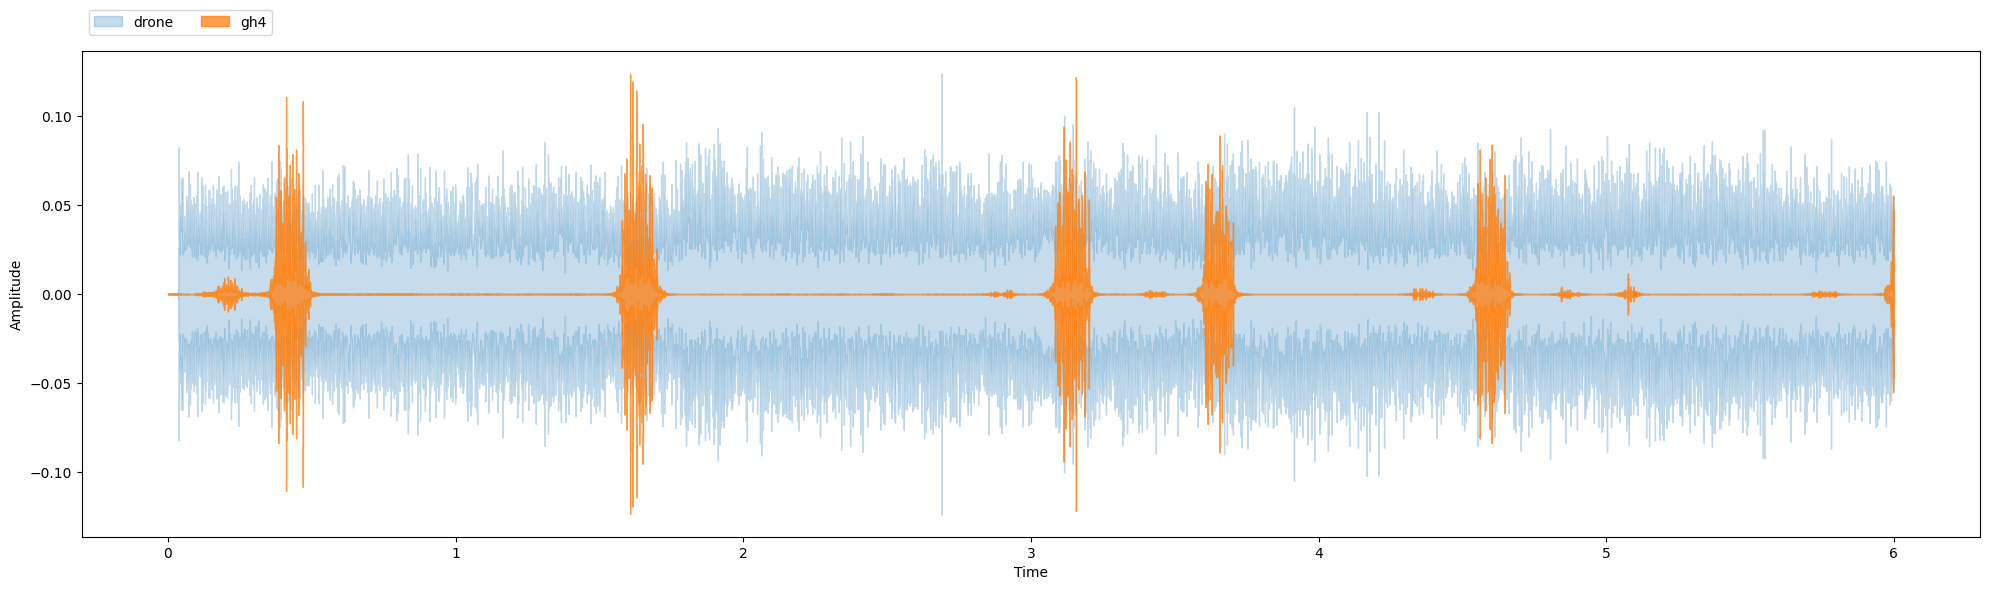

In [5]:
drone_s = nussl.AudioSignal(audio_data_array=drone, sample_rate=sr_drone)
gh4_s = nussl.AudioSignal(audio_data_array=gh4, sample_rate=sr_gh4)
show_sources({'gh4': gh4_s, 'drone': drone_s})

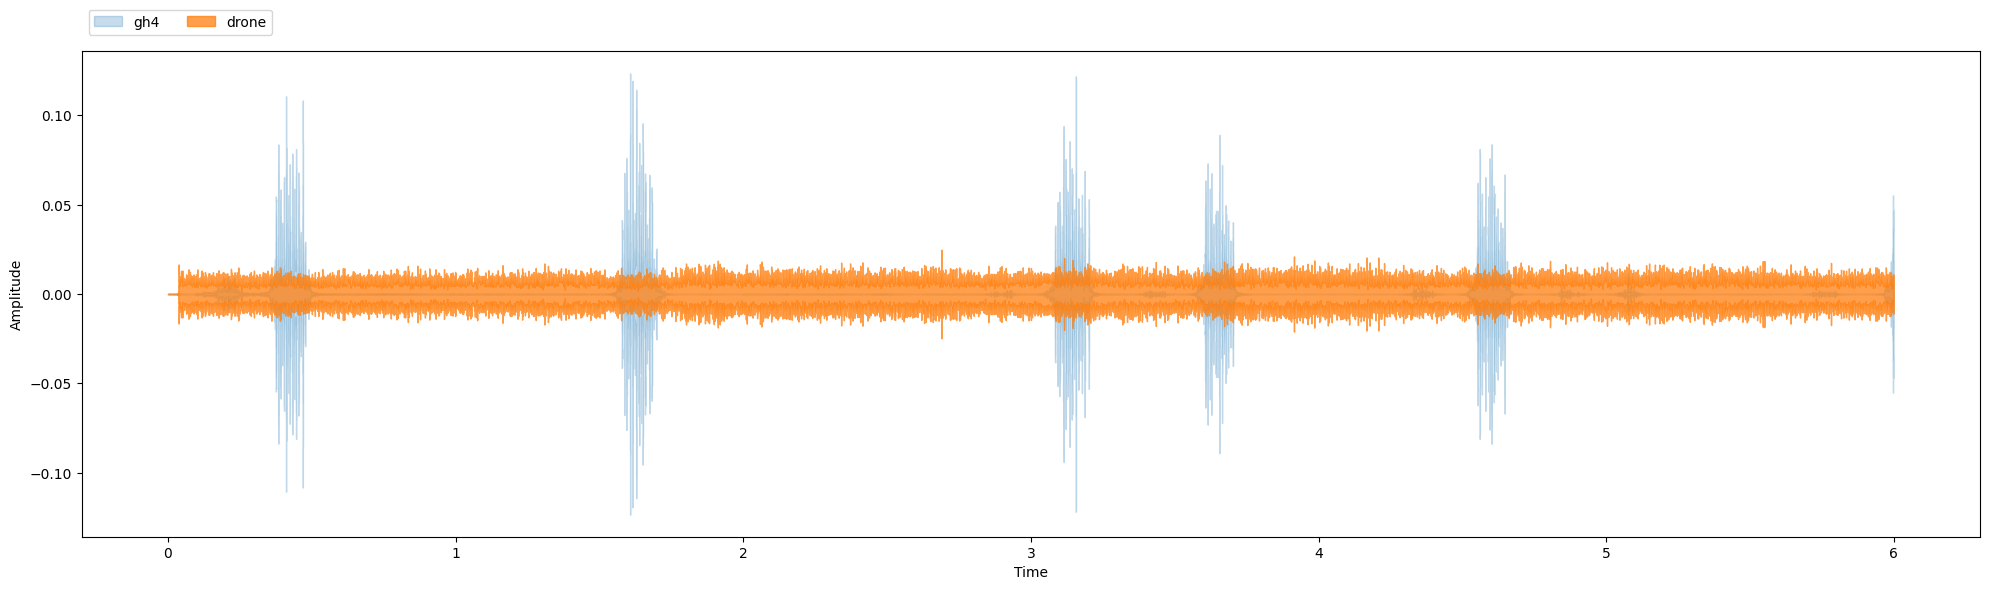

In [6]:

drone_half_s = nussl.AudioSignal(audio_data_array=drone_half, sample_rate=sr_drone_half)
show_sources({'gh4': gh4_s, 'drone': drone_half_s})

In [3]:
# Let's download a file from the External File Zoo
input_file_path = nussl.efz_utils.download_audio_file('schoolboy_fascination_excerpt.wav')
signal1 = nussl.AudioSignal(input_file_path)
print(signal1)
_ = signal1.embed_audio()

Matching file found at /home/zhangjw/.nussl/audio/schoolboy_fascination_excerpt.wav, skipping download.
AudioSignal (unlabeled): 15.000 sec @ /home/zhangjw/.nussl/audio/schoolboy_fascination_excerpt.wav, 44100 Hz, 2 ch.


ffmpeg version 5.1.1-1ubuntu1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 12 (Ubuntu 12.2.0-1ubuntu1)
  configuration: --prefix=/usr --extra-version=1ubuntu1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librist --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtheora --enable-libtwolame --enable-libvidstab --

In [4]:
print("Duration: {} seconds".format(signal1.signal_duration))
print("Duration in samples: {} samples".format(signal1.signal_length))
print("Number of channels: {} channels".format(signal1.num_channels))
print("File name: {}".format(signal1.file_name))
print("Full path to input: {}".format(signal1.path_to_input_file))
print("Root mean square energy: {:.4f}".format(signal1.rms().mean()))

Duration: 15.0 seconds
Duration in samples: 661500 samples
Number of channels: 2 channels
File name: schoolboy_fascination_excerpt.wav
Full path to input: /home/zhangjw/.nussl/audio/schoolboy_fascination_excerpt.wav
Root mean square energy: 0.1136


In [5]:
print(signal1.audio_data)
print(signal1.audio_data.shape)

[[ 0.00213623 -0.04547119 -0.0513916  ... -0.24395752 -0.2310791
  -0.20785522]
 [-0.1791687  -0.20150757 -0.20574951 ... -0.23834229 -0.2156372
  -0.168396  ]]
(2, 661500)


In [7]:
sample_rate = 44100  # Hz
dt = 1.0 / sample_rate
dur = 2.0  # seconds
freq = 440  # Hz
x = np.arange(0.0, dur, dt)
x = np.sin(2 * np.pi * freq * x)

signal2 = nussl.AudioSignal(audio_data_array=x, sample_rate=sample_rate)
signal2.embed_audio()
print(signal2)

ffmpeg version 5.1.1-1ubuntu1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 12 (Ubuntu 12.2.0-1ubuntu1)
  configuration: --prefix=/usr --extra-version=1ubuntu1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librist --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtheora --enable-libtwolame --enable-libvidstab --

AudioSignal (unlabeled): 2.000 sec @ path unknown, 44100 Hz, 1 ch.


In [31]:
print(signal1.to_mono(overwrite=True))
signal1.truncate_seconds(signal2.signal_duration)
print(signal1)

signal3 = signal1 + signal2
signal3.peak_normalize()
signal3.embed_audio()
print(signal3)

AudioSignal (unlabeled): 15.000 sec @ /home/zhangjw/.nussl/audio/schoolboy_fascination_excerpt.wav, 44100 Hz, 1 ch.
AudioSignal (unlabeled): 2.000 sec @ /home/zhangjw/.nussl/audio/schoolboy_fascination_excerpt.wav, 44100 Hz, 1 ch.


ffmpeg version 5.1.1-1ubuntu1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 12 (Ubuntu 12.2.0-1ubuntu1)
  configuration: --prefix=/usr --extra-version=1ubuntu1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librist --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtheora --enable-libtwolame --enable-libvidstab --

AudioSignal (unlabeled): 2.000 sec @ /home/zhangjw/.nussl/audio/schoolboy_fascination_excerpt.wav, 44100 Hz, 1 ch.


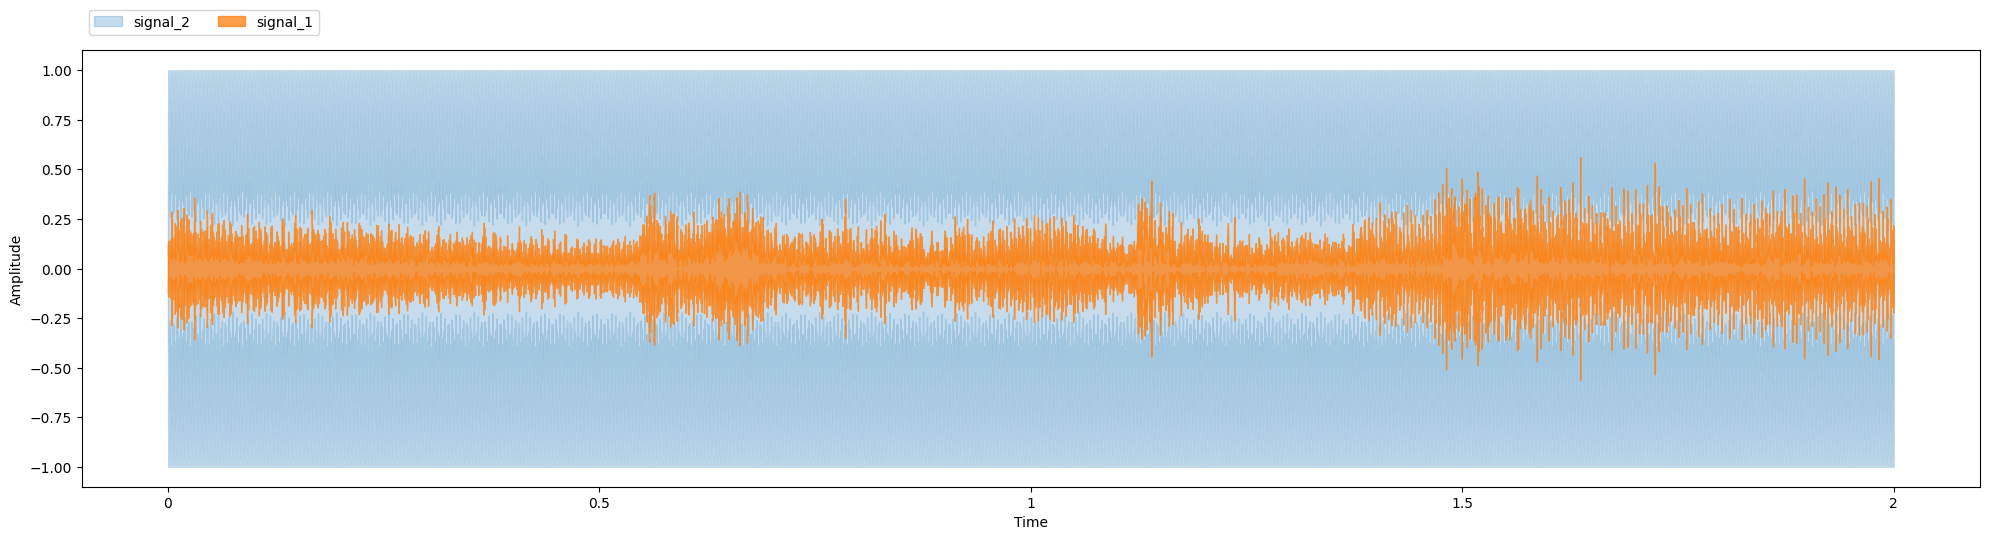

In [32]:
show_sources({'signal_1': signal1, 'signal_2': signal2})

In [10]:
signal3.write_audio_to_file('../signal3.wav')

In [12]:
signal1 = nussl.AudioSignal(input_file_path)
print('STFT Data:', signal1.stft_data)

stft = signal1.stft()
print(stft.shape)

print(signal1.stft_data.shape)

# np.abs(signal1.stft_data) ** 2
psd = signal1.power_spectrogram_data
print(psd.shape)



STFT Data: None
(1025, 1293, 2)
(1025, 1293, 2)
(1025, 1293, 2)


/home/zhangjw/.cache/pypoetry/virtualenvs/pestdataprocess-pxU8UH9y-py3.10/lib/python3.10/site-packages/nussl/core/utils.py:418: FutureWarning: Pass y=[ 0.00213623 -0.04547119 -0.0513916  ... -0.24395752 -0.2310791
 -0.20785522] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  data = librosa.feature.melspectrogram(audio_signal.get_channel(ch),


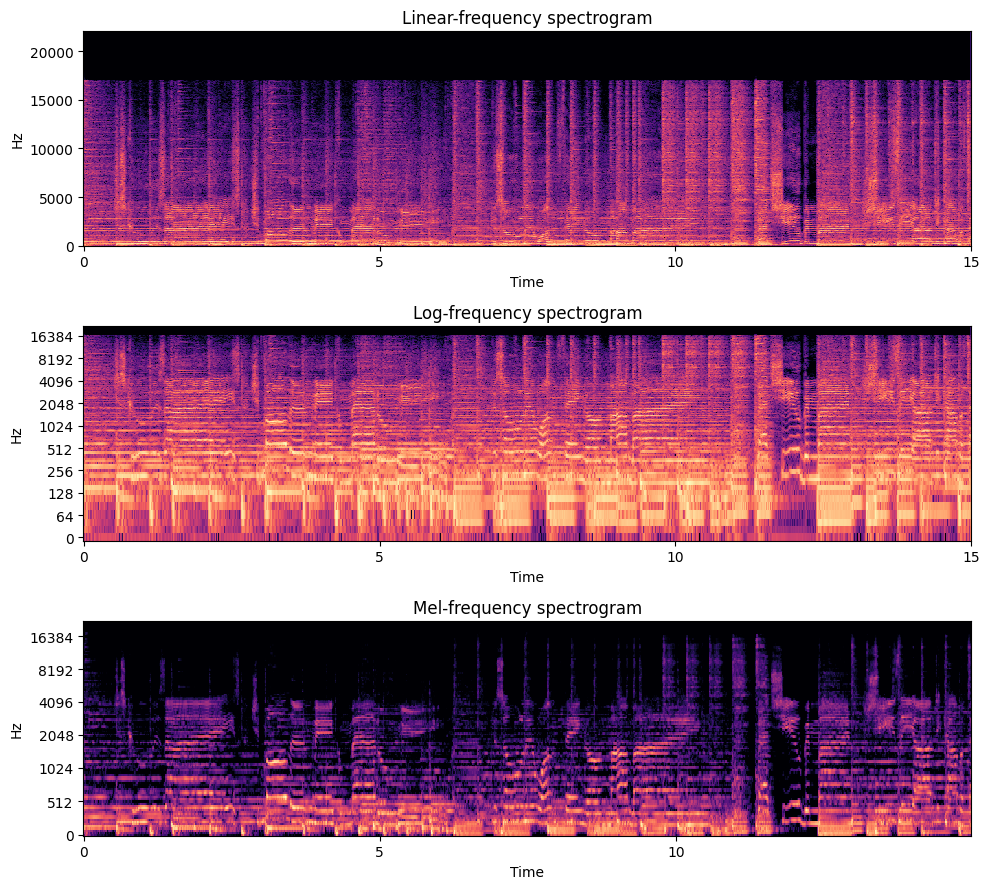

In [13]:
plt.figure(figsize=(10, 9))
plt.subplot(311)
plt.title('Linear-frequency spectrogram')
nussl.utils.visualize_spectrogram(signal1)

plt.subplot(312)
plt.title('Log-frequency spectrogram')
nussl.utils.visualize_spectrogram(signal1, y_axis='log')

plt.subplot(313)
plt.title('Mel-frequency spectrogram')
nussl.utils.visualize_spectrogram(signal1, y_axis='mel')

plt.tight_layout()
plt.show()


In [14]:
lp_stft = signal1.stft_data.copy()
lp_cutoff = 1000  # Hz
frequency_vector = signal1.freq_vector  # a vector of frequency values for each FFT bin
idx = (np.abs(frequency_vector - lp_cutoff)).argmin()  # trick to find the index of the closest value to lp_cutoff
lp_stft[idx:, :, :] = 0.0j  # every freq above lp_cutoff is 0 now

signal1_lp = signal1.make_copy_with_stft_data(lp_stft)
print('Audio Data:', signal1_lp.audio_data)

signal1_lp.istft()
signal1_lp.embed_audio()
print(signal1_lp)

Audio Data: None


ffmpeg version 5.1.1-1ubuntu1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 12 (Ubuntu 12.2.0-1ubuntu1)
  configuration: --prefix=/usr --extra-version=1ubuntu1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librist --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtheora --enable-libtwolame --enable-libvidstab --

AudioSignal (unlabeled): 15.000 sec @ /home/zhangjw/.nussl/audio/schoolboy_fascination_excerpt.wav, 44100 Hz, 2 ch.


/home/zhangjw/.cache/pypoetry/virtualenvs/pestdataprocess-pxU8UH9y-py3.10/lib/python3.10/site-packages/nussl/core/utils.py:418: FutureWarning: Pass y=[ 0.01081682  0.01089952  0.01079562 ... -0.15169713 -0.14302352
 -0.13376865] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  data = librosa.feature.melspectrogram(audio_signal.get_channel(ch),


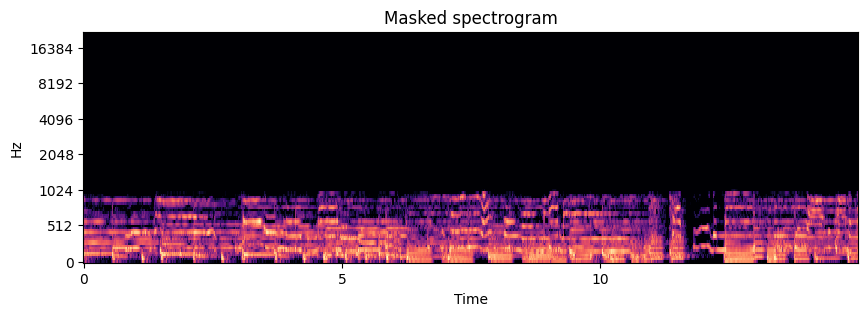

In [15]:
plt.figure(figsize=(10, 3))
plt.title('Masked spectrogram')
nussl.utils.visualize_spectrogram(signal1_lp, y_axis='mel')
plt.show()